In [13]:
import keras
from sklearn.model_selection import train_test_split
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train_scaled = x_train.reshape(-1, 28, 28, 1) / 255.0
x_train_scaled, val_scaled, y_train, val_target = train_test_split(x_train_scaled, y_train, test_size=0.2, random_state=42)

In [14]:
x_train_scaled.shape, val_scaled.shape, y_train.shape, val_target.shape

((48000, 28, 28, 1), (12000, 28, 28, 1), (48000,), (12000,))

In [15]:
from keras import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    MaxPooling2D(2),
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling2D(2),
    Flatten(),
    Dense(100, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(x_train_scaled, y_train, epochs=20, 
                    validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8126 - loss: 0.5298 - val_accuracy: 0.8808 - val_loss: 0.3244
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8762 - loss: 0.3448 - val_accuracy: 0.8956 - val_loss: 0.2829
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8940 - loss: 0.2964 - val_accuracy: 0.8973 - val_loss: 0.2697
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9046 - loss: 0.2641 - val_accuracy: 0.9145 - val_loss: 0.2380
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9133 - loss: 0.2366 - val_accuracy: 0.9118 - val_loss: 0.2482
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9210 - loss: 0.2169 - val_accuracy: 0.9189 - val_loss: 0.2273
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9262 - loss: 0.2019 - val_accuracy: 0.9208 - val_loss: 0.2202
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9323 - loss: 0

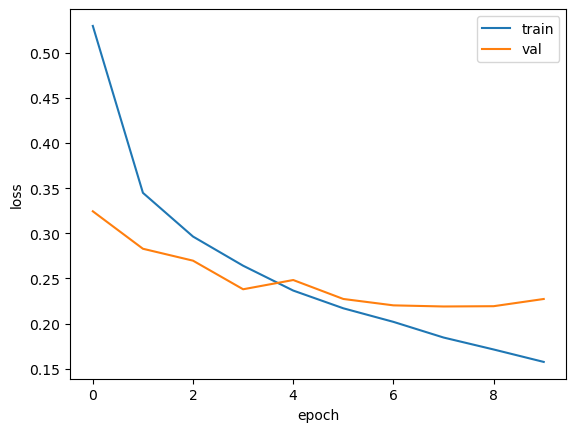

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [18]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9242 - loss: 0.2189


[0.2189304232597351, 0.9241666793823242]

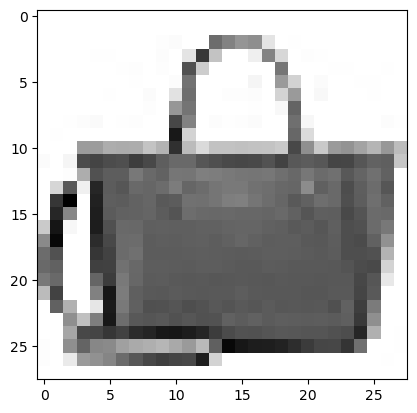

In [19]:
plt.imshow(val_scaled[0].reshape(28,28), cmap='gray_r')
plt.show()

In [20]:
preds = model.predict(val_scaled[0:1])
preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


array([[6.2732716e-19, 1.2181492e-26, 1.1664760e-24, 7.1143082e-24,
        1.3343878e-20, 3.2078261e-20, 2.6150362e-21, 2.8744334e-21,
        1.0000000e+00, 1.7266088e-20]], dtype=float32)

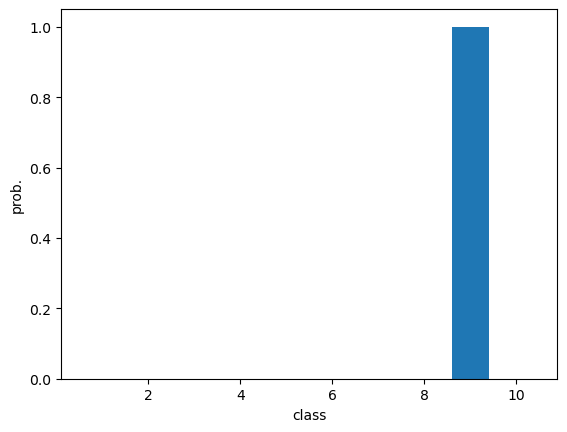

In [21]:
plt.bar(range(1,11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()

In [22]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

In [23]:
import numpy as np
classes[np.argmax(preds)]

'가방'

In [25]:
x_test_scaled = x_test.reshape(-1, 28, 28, 1) /255.0
model.evaluate(x_test_scaled, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9180 - loss: 0.2410


[0.2409932166337967, 0.9179999828338623]